In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Colormap, ListedColormap
import seaborn as sns


In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=200, n_features=2,
    n_informative=2, n_redundant=0,
    random_state=42
)


data = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))),
                    columns=['x1', 'x2', 'y'])

__Задание 1.__

Обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделяющую поверхность на трейне (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились? (2б)

In [3]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

### Your code is here

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
model.score(X_train, y_train)

1.0

In [13]:
model.score(X_test, y_test)

0.8

In [11]:
y_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred)
print(f"accuracy on train is {train_accuracy}")

accuracy on train is 1.0


In [9]:
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy on test is {test_accuracy}")

accuracy on test is 0.8


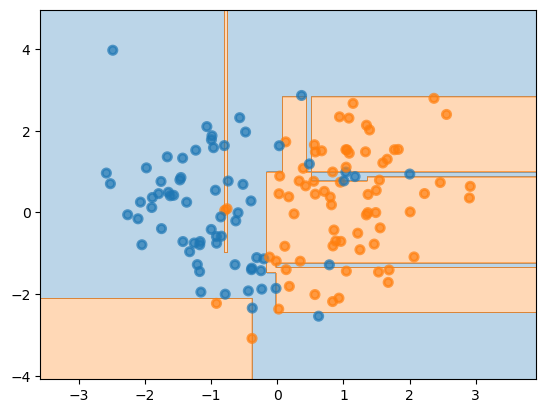

In [14]:
plot_surface(model, X_train, y_train)

__Задание 2.__

Переберите несколько параметров для регуляризации (`max_depth`, `min_samples_leaf`) из предложенных. Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Используйте, если хотите, функцию ниже. Как изменение параметров влияет на поверхность? При каких параметрах на тесте достигается лучшее качество? А на трейне? (2б).

In [15]:
def plot_surface_axes(clf, X, y, ax, train_acc, test_acc):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
    edgecolors=np.array(palette)[y], linewidths=2)
    
    ax.plot([], [], label = 'train_acc : %0.5f' % train_acc)
    ax.plot([], [], label = 'test_acc : %0.5f' % test_acc)
    
    plt.legend(loc = 'lower right', prop={'size': 20})

In [16]:
max_depth_set = [6, 7, 8, 9, 12]

min_samples_leaf_set = [3, 5, 7, 10]

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state = 42) 

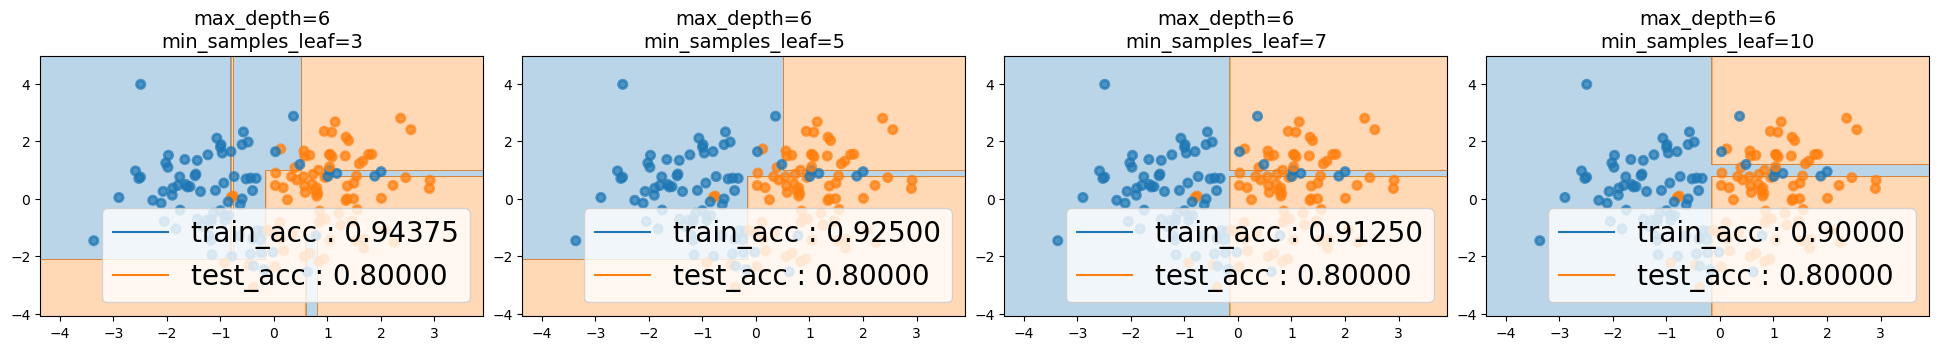

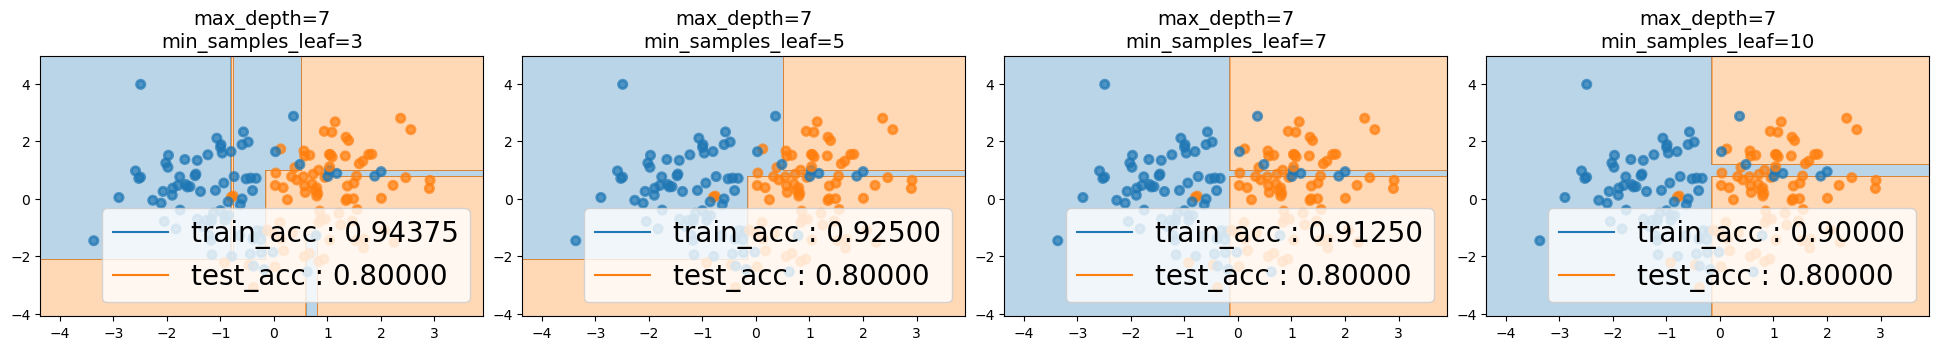

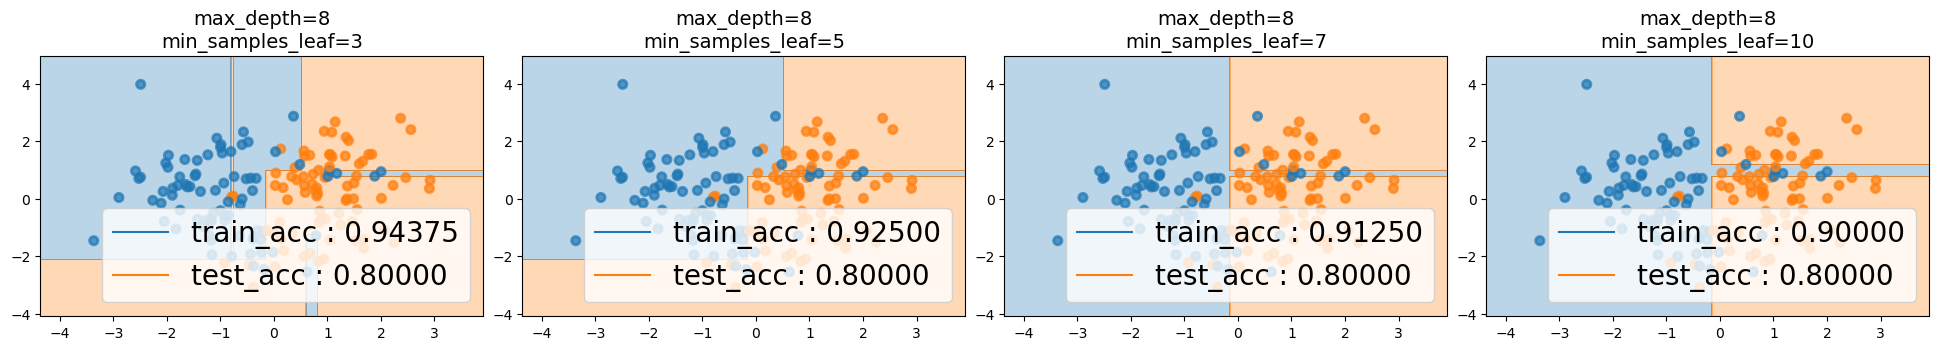

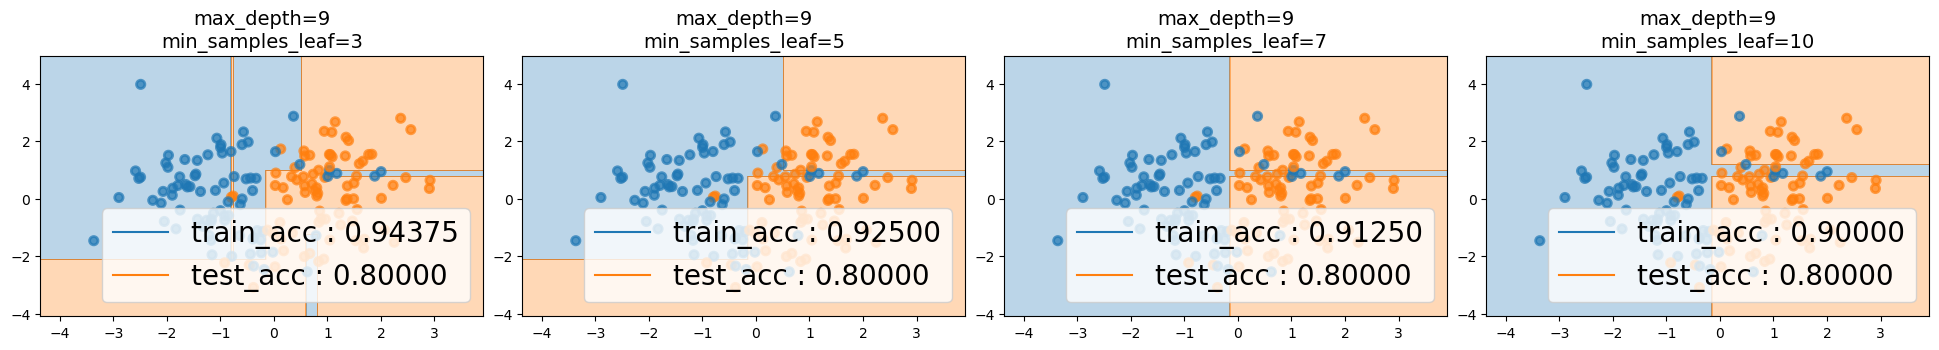

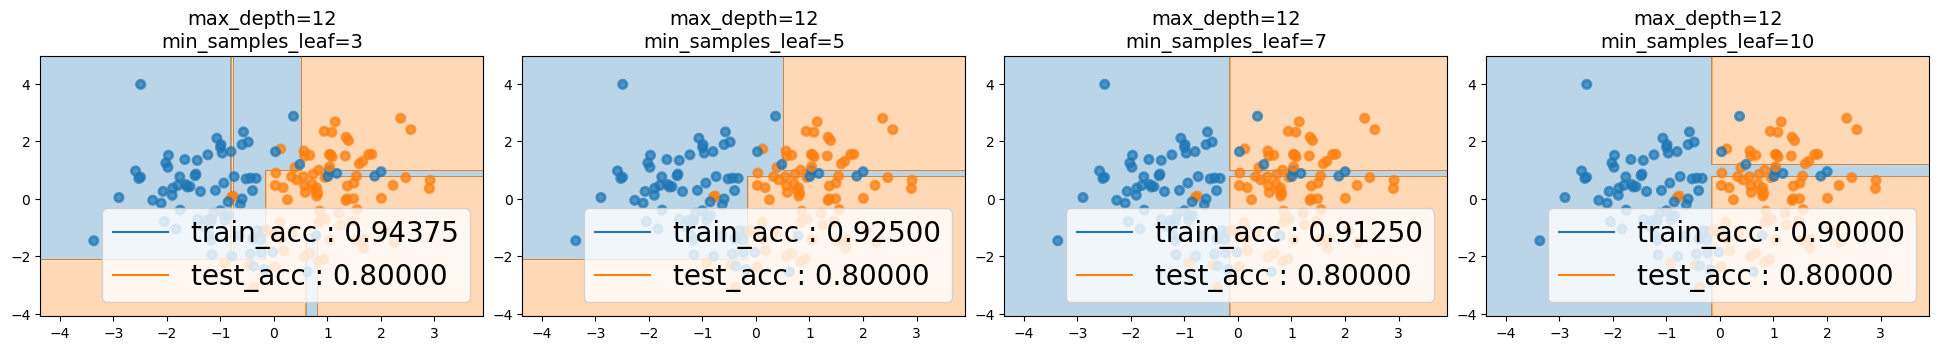

Лучшие гиперпараметры на трейне:
max_depth = 6
min_samples_leaf = 3
Train accuracy = 0.94375


In [44]:
best_train_acc = 0
best_train_params = None

for max_depth in max_depth_set:
    
    f = plt.figure(figsize=(5 * len(min_samples_leaf_set), 4))
    
    for k, min_samples_leaf in enumerate(min_samples_leaf_set, start=1):
        
        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        
        tree.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, tree.predict(X_train))
        test_acc = accuracy_score(y_test, tree.predict(X_test))
        
        if train_acc > best_train_acc:
            best_train_acc = train_acc
            best_train_params = (max_depth, min_samples_leaf)
        
        ax = f.add_subplot(1, len(min_samples_leaf_set), k)
        
        plot_surface_axes(tree, X_train, y_train, ax, train_acc, test_acc)
        ax.set_title(
            f"max_depth={max_depth}\nmin_samples_leaf={min_samples_leaf}",
            fontsize=14
        )
    
    plt.show()

print("Лучшие гиперпараметры на трейне:")
print("max_depth =", best_train_params[0])
print("min_samples_leaf =", best_train_params[1])
print("Train accuracy =", best_train_acc)


__Задание 3.__

Добавим признак $2\cdot x_1 - x_2$, транформацию добавим как шаг пайплайна. С помощью данного класса (из практики/лекции) обучите дерево с максимальной глубиной=3, нарисуйте поверхность на трейне, посчитайте accuracy (2 б)

In [57]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomFunctionTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, first_col, second_col, function):
        self.first_col = first_col
        self.second_col = second_col
        self.function = function
        print("Инициализировали класс!")
        
    def fit(self, X, y=None):
        print("Зафитили датасет!")
        return self
    
    def transform(self, X, y=None):
        
        X_ = X.copy()
        X_['new_feature'] = self.function(X_[self.first_col], X_[self.second_col])
        X_ = X_.drop([self.first_col, self.second_col], axis=1)
        
        print("Трансформировали датасет!")
        return X_

In [58]:
X_train = pd.DataFrame(X_train, columns=['x1', 'x2'])
X_test = pd.DataFrame(X_test, columns=['x1', 'x2'])

In [65]:
from sklearn.pipeline import Pipeline

# pipeline 
pipe = Pipeline([
    ("custom_transformer", CustomFunctionTransformer(
        "x1", "x2", lambda x, y: 2 * x - y
    )),
    ("decision_tree", DecisionTreeClassifier(max_depth=3, random_state=42))
])

# обучение
pipe.fit(X_train, y_train)

# accuracy
train_acc = accuracy_score(y_train, pipe.predict(X_train))
test_acc = accuracy_score(y_test, pipe.predict(X_test))
print(train_acc, test_acc)

Инициализировали класс!
Зафитили датасет!
Трансформировали датасет!
Трансформировали датасет!
Трансформировали датасет!
0.8625 0.75


Трансформировали датасет!


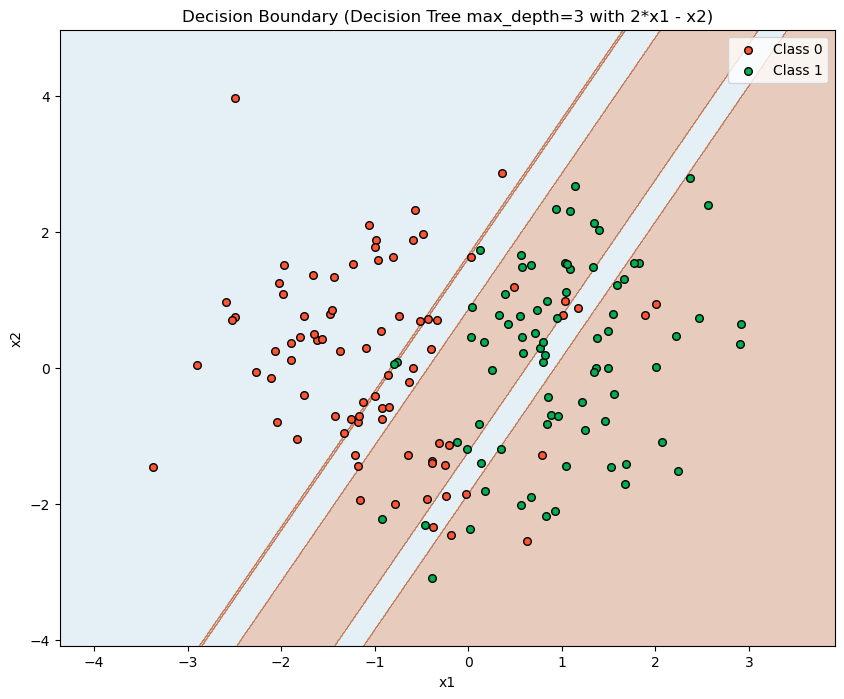

0.86
0.75


In [67]:
# Визуализация разделяющей поверхности
fig = plt.figure(figsize=(10, 8))

pixel_step = 0.01
x1_min, x1_max = X_train['x1'].min() - 1, X_train['x1'].max() + 1
x2_min, x2_max = X_train['x2'].min() - 1, X_train['x2'].max() + 1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, pixel_step),
    np.arange(x2_min, x2_max, pixel_step)
)

grid_df = pd.DataFrame(np.c_[xx1.ravel(), xx2.ravel()], columns=['x1','x2'])
Z = pipe.predict(grid_df).reshape(xx1.shape)

plt.contourf(xx1, xx2, Z, cmap=plt.cm.Paired, alpha=0.3)

# Рисуем точки трейна
for i, n, c in zip(range(len(pipe.classes_)), pipe.classes_, ["#FF5533", "#00B050"]):
    idx = np.where(y_train == i)
    plt.scatter(
        X_train.values[idx, 0],
        X_train.values[idx, 1],
        c=c,
        s=30,
        edgecolor='k',
        label=f"Class {n}"
    )

plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary (Decision Tree max_depth=3 with 2*x1 - x2)")
plt.legend()
plt.show()

# Вывод accuracy для задания
print(f"{train_acc:.2f}")
print(f"{test_acc:.2f}")